In [21]:
import sys

from pathlib import Path
import matplotlib.pyplot as plt

from desilike.samples import MCSamples, Profiles, plotting
from cosmoprimo.fiducial import AbacusSummit

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

params_toplot = ['omega_b', 'omega_cdm', 'logA', 'h', 'n_s', 'ELG2.b1', 'ELG2.b2', 'ELG2.bs', 'ELG2.auw', 'sigma8_m'][1:-1]

cosmo = AbacusSummit()
truth = {}
for p in params_toplot:
    try:
        truth[p] = cosmo[p]
    except:
        continue
truth['ELG2.auw'] = 1.

def read_samples(fn, burnin=False, thin=False):
    if isinstance(fn, list):
        samples = MCSamples.concatenate([MCSamples.read(fn).remove_burnin(burnin if burnin else 0.) for fn in fn])
    else:
        samples = MCSamples.read(fn)
    if thin:
        samples = samples[::thin]
    return samples

plot_dir = Path('validation_fiber_assignment')
plot_dir.mkdir(exist_ok=True)
ext = 'png'

## AbacusHF mock

Removed no burn in
Removed no burn in


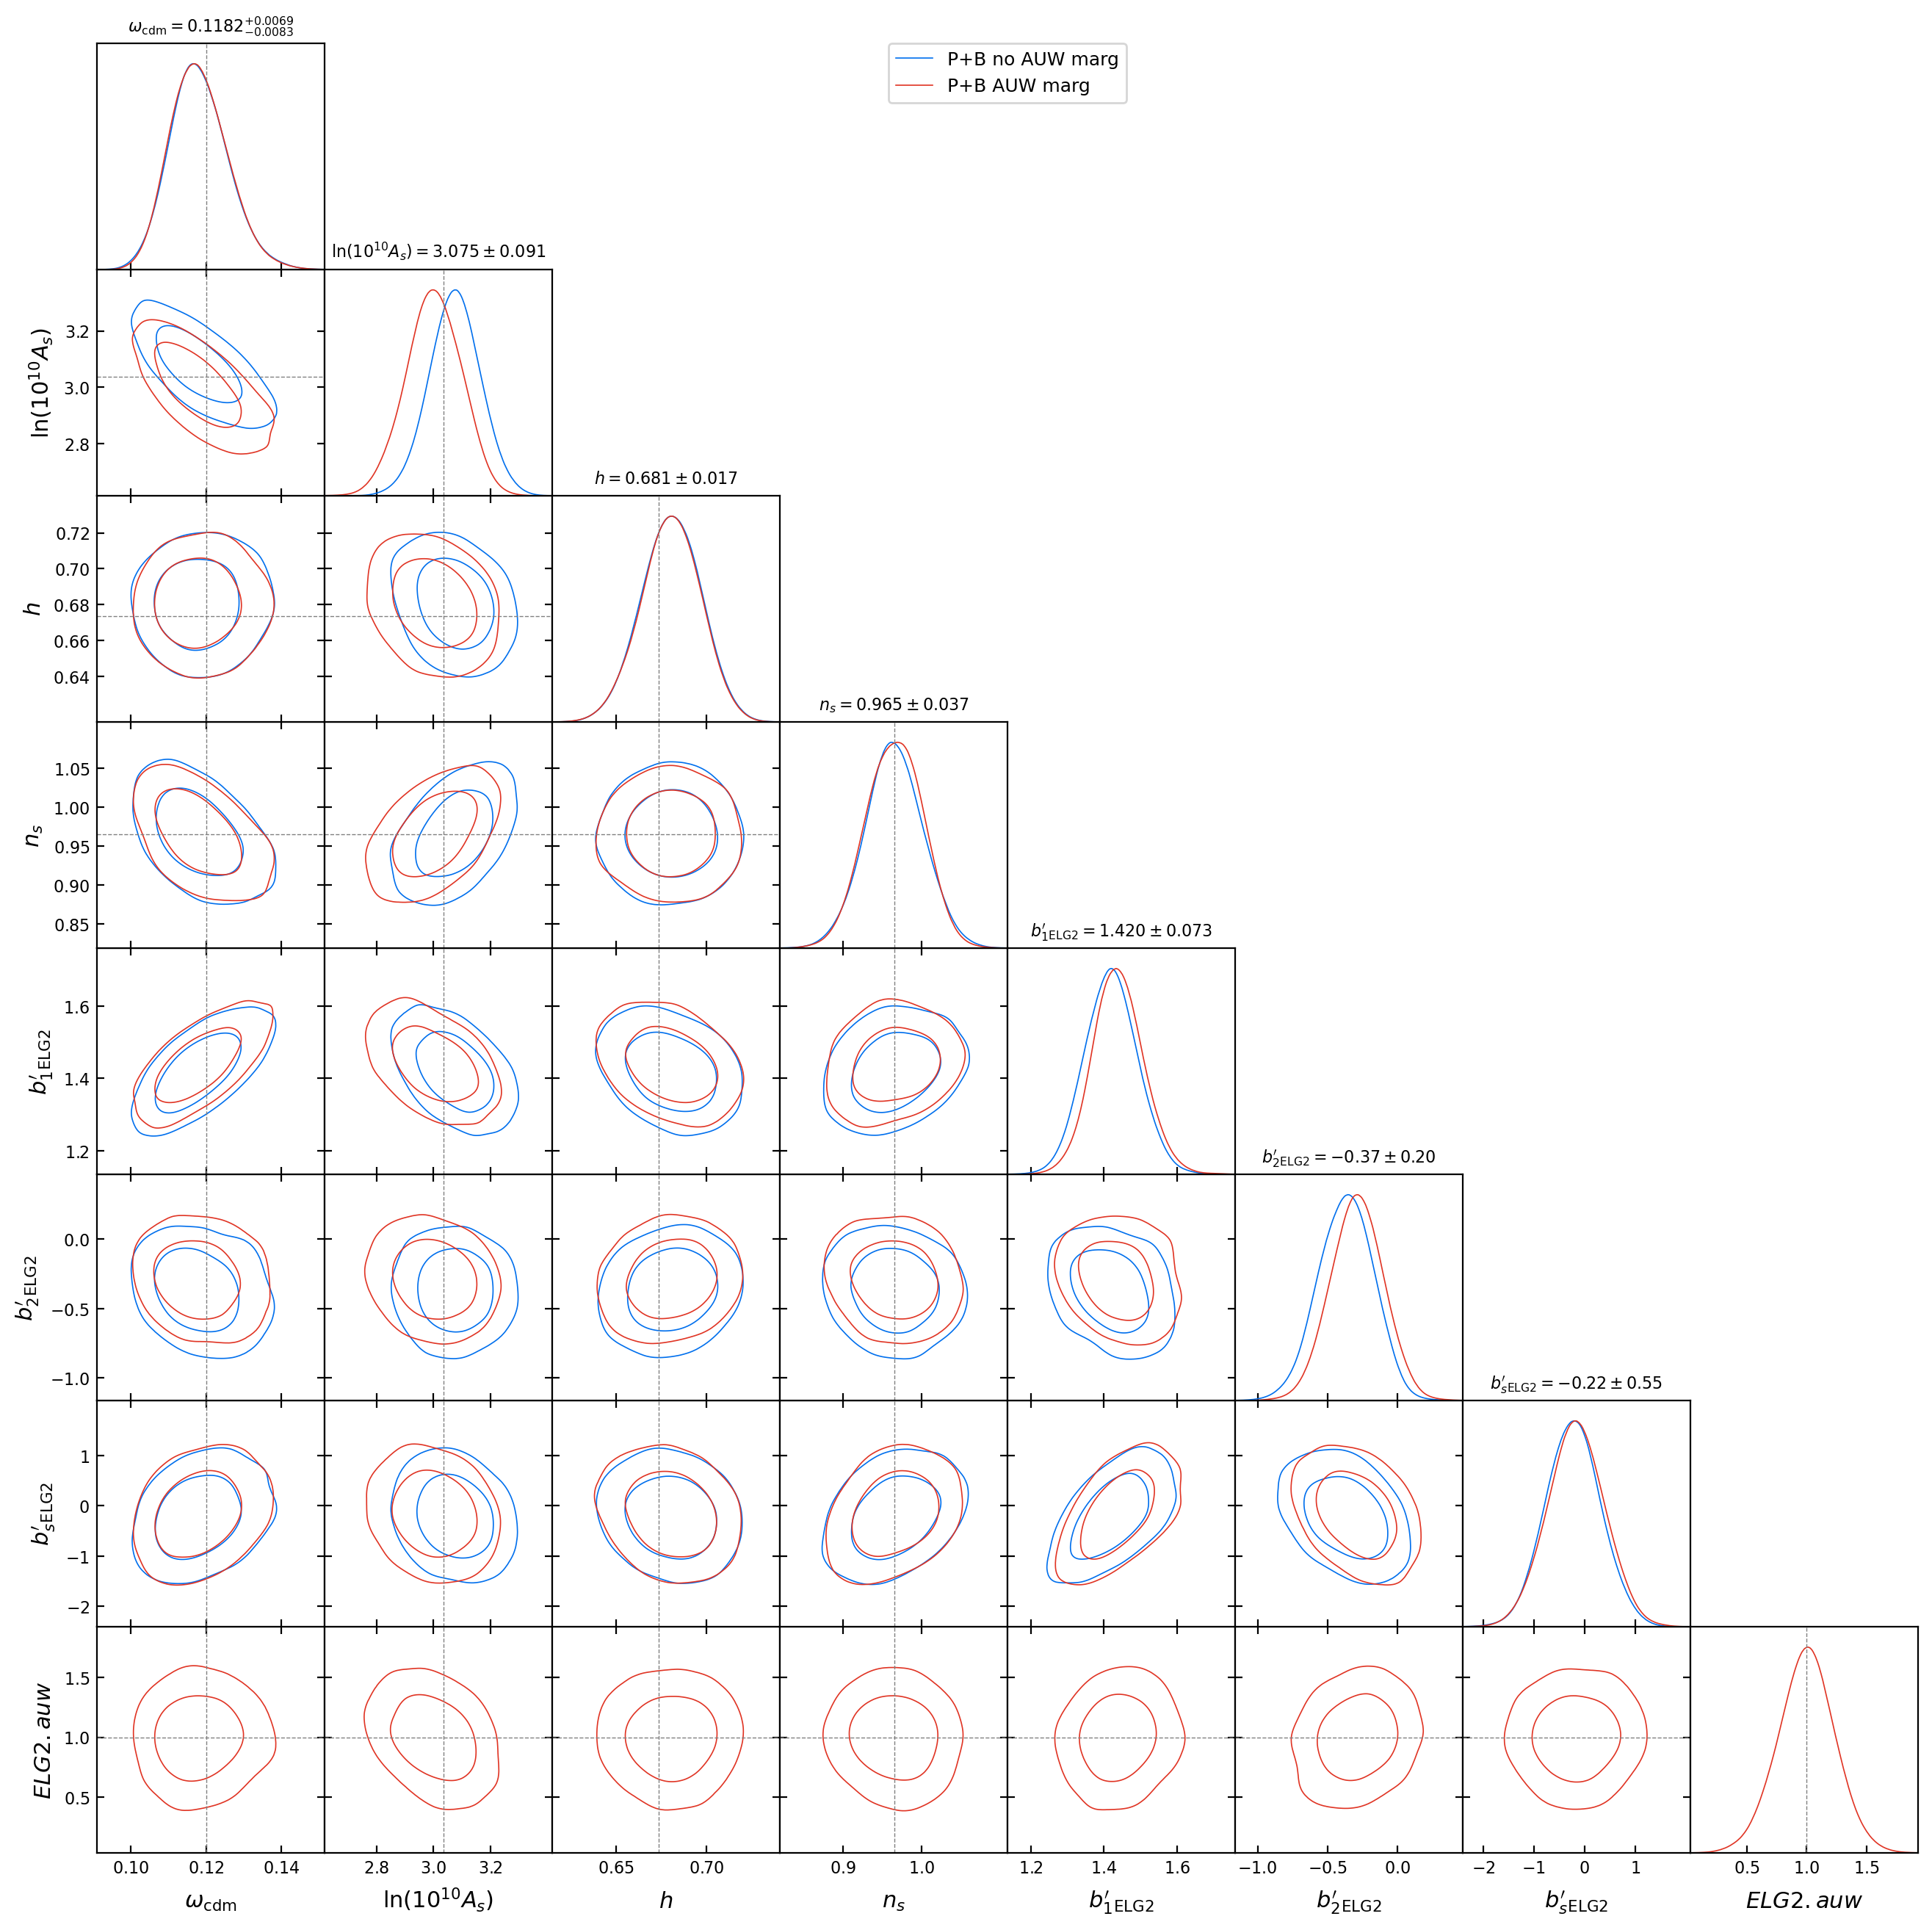

In [22]:
dirname = Path('/pscratch/sd/a/adematti/fits_systematic_templates/abacus-hf-dr2-v2-altmtl/')
samples, legends = [], []
#samples.append(read_samples([dirname / f'cosmo-base_ELG2-S2-21e7c046/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
#legends.append('P no AUW marg')
samples.append(read_samples([dirname / f'cosmo-base_ELG2-S2+ELG2-S3-1a5c1386/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('P+B no AUW marg')
samples.append(read_samples([dirname / f'cosmo-base_ELG2-S2-w-auw+ELG2-S3-w-auw-adac9cd6/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('P+B AUW marg')
plotting.plot_triangle(samples, params=params_toplot, title_limit=1, markers=truth, legend_labels=legends)
fig = plt.gcf()
fig.savefig(plot_dir / f'triangle.{ext}', bbox_inches='tight', pad_inches=0.1, dpi=200)
plt.show()

In [19]:
print(samples[0].to_stats(tablefmt='pretty'))
print(samples[1].to_stats(tablefmt='pretty'))

+------------+---------+---------+---------+---------+-----------------+-----------------+
|            | argmax  |  mean   | median  |   std   | quantile:1sigma | interval:1sigma |
+------------+---------+---------+---------+---------+-----------------+-----------------+
|     h      |  0.683  |  0.681  |  0.681  |  0.017  |  +0.017/-0.017  |  +0.017/-0.016  |
|  omega_b   | 0.02261 | 0.02239 | 0.02240 | 0.00055 | +5.5e-4/-5.5e-4 | +5.5e-4/-5.5e-4 |
| omega_cdm  | 0.1256  | 0.1182  | 0.1177  | 0.0078  | +0.0077/-0.0076 | +0.0070/-0.0082 |
|    logA    |  3.010  |  3.075  |  3.075  |  0.091  |  +0.090/-0.090  |  +0.091/-0.089  |
|    n_s     |  0.953  |  0.965  |  0.965  |  0.037  |  +0.037/-0.037  |  +0.037/-0.037  |
|  ELG2.b1   |  1.485  |  1.420  |  1.419  |  0.073  |  +0.072/-0.073  |  +0.073/-0.072  |
|  ELG2.b2   |  -0.12  |  -0.37  |  -0.36  |  0.20   |   +0.20/-0.20   |   +0.21/-0.18   |
|  ELG2.bs   |  -0.18  |  -0.22  |  -0.22  |  0.55   |   +0.55/-0.55   |   +0.52/-0.57   |

Removed no burn in
Removed no burn in


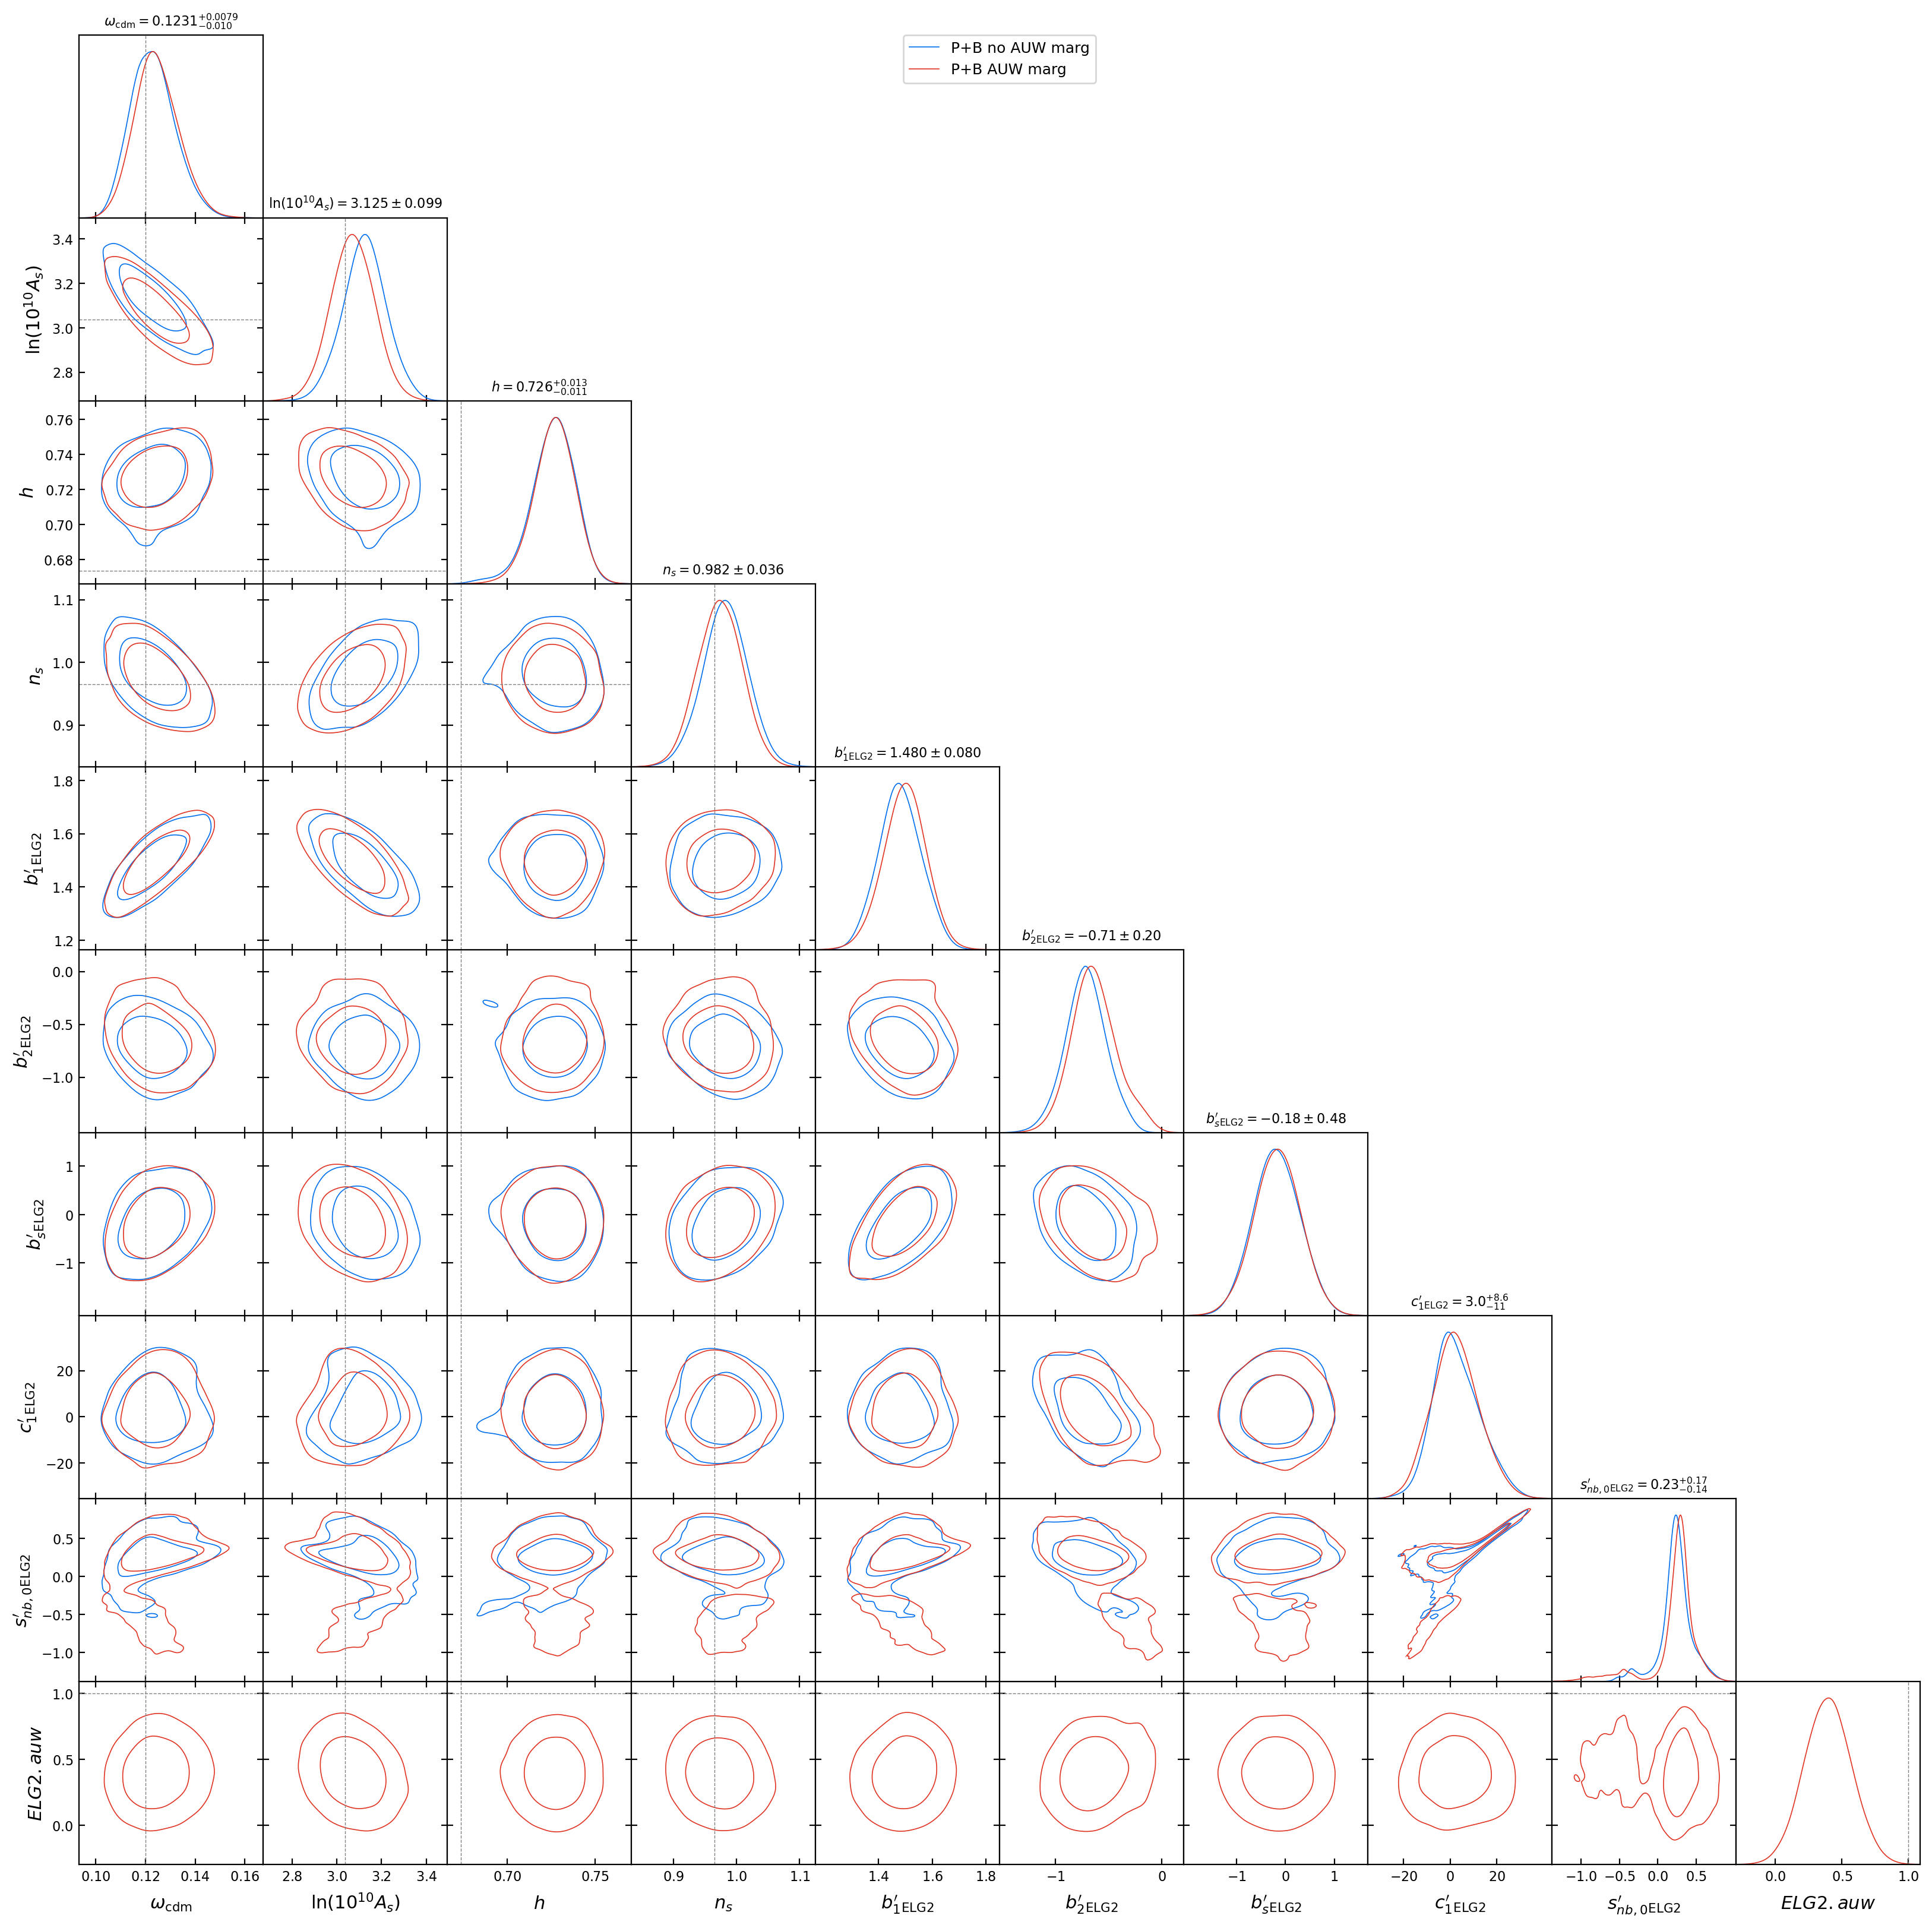

In [30]:
dirname = Path('/pscratch/sd/a/adematti/fits_systematic_templates/data-dr2-v2/')
params_toplot = ['omega_cdm', 'logA', 'h', 'n_s', 'ELG2.auw'] #, 'ELG2.b1', 'ELG2.b2', 'ELG2.bs', 'ELG2.c1', 'ELG2.snb0'] #['ELG2.alpha0', 'ELG2.alpha2', 'ELG2.alpha4', 'ELG2.sn0', 'ELG2.sn2', 'ELG2.sn4', 'ELG2.auw']

samples, legends = [], []
#samples.append(read_samples([dirname / f'cosmo-base_ELG2-S2-21e7c046/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
#legends.append('P no AUW marg')
samples.append(read_samples([dirname / f'cosmo-base_ELG2-S2+ELG2-S3-4464f84d/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('P+B no AUW marg')
samples.append(read_samples([dirname / f'cosmo-base_ELG2-S2-w-auw+ELG2-S3-w-auw-d95296ad/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('P+B AUW marg')
plotting.plot_triangle(samples, params=params_toplot, title_limit=1, markers=truth, legend_labels=legends)
fig = plt.gcf()
fig.savefig(plot_dir / f'triangle.{ext}', bbox_inches='tight', pad_inches=0.1, dpi=200)
plt.show()

In [24]:
samples[1].std('ELG2.auw')

np.float64(0.18012029629707402)

Removed no burn in
Removed no burn in


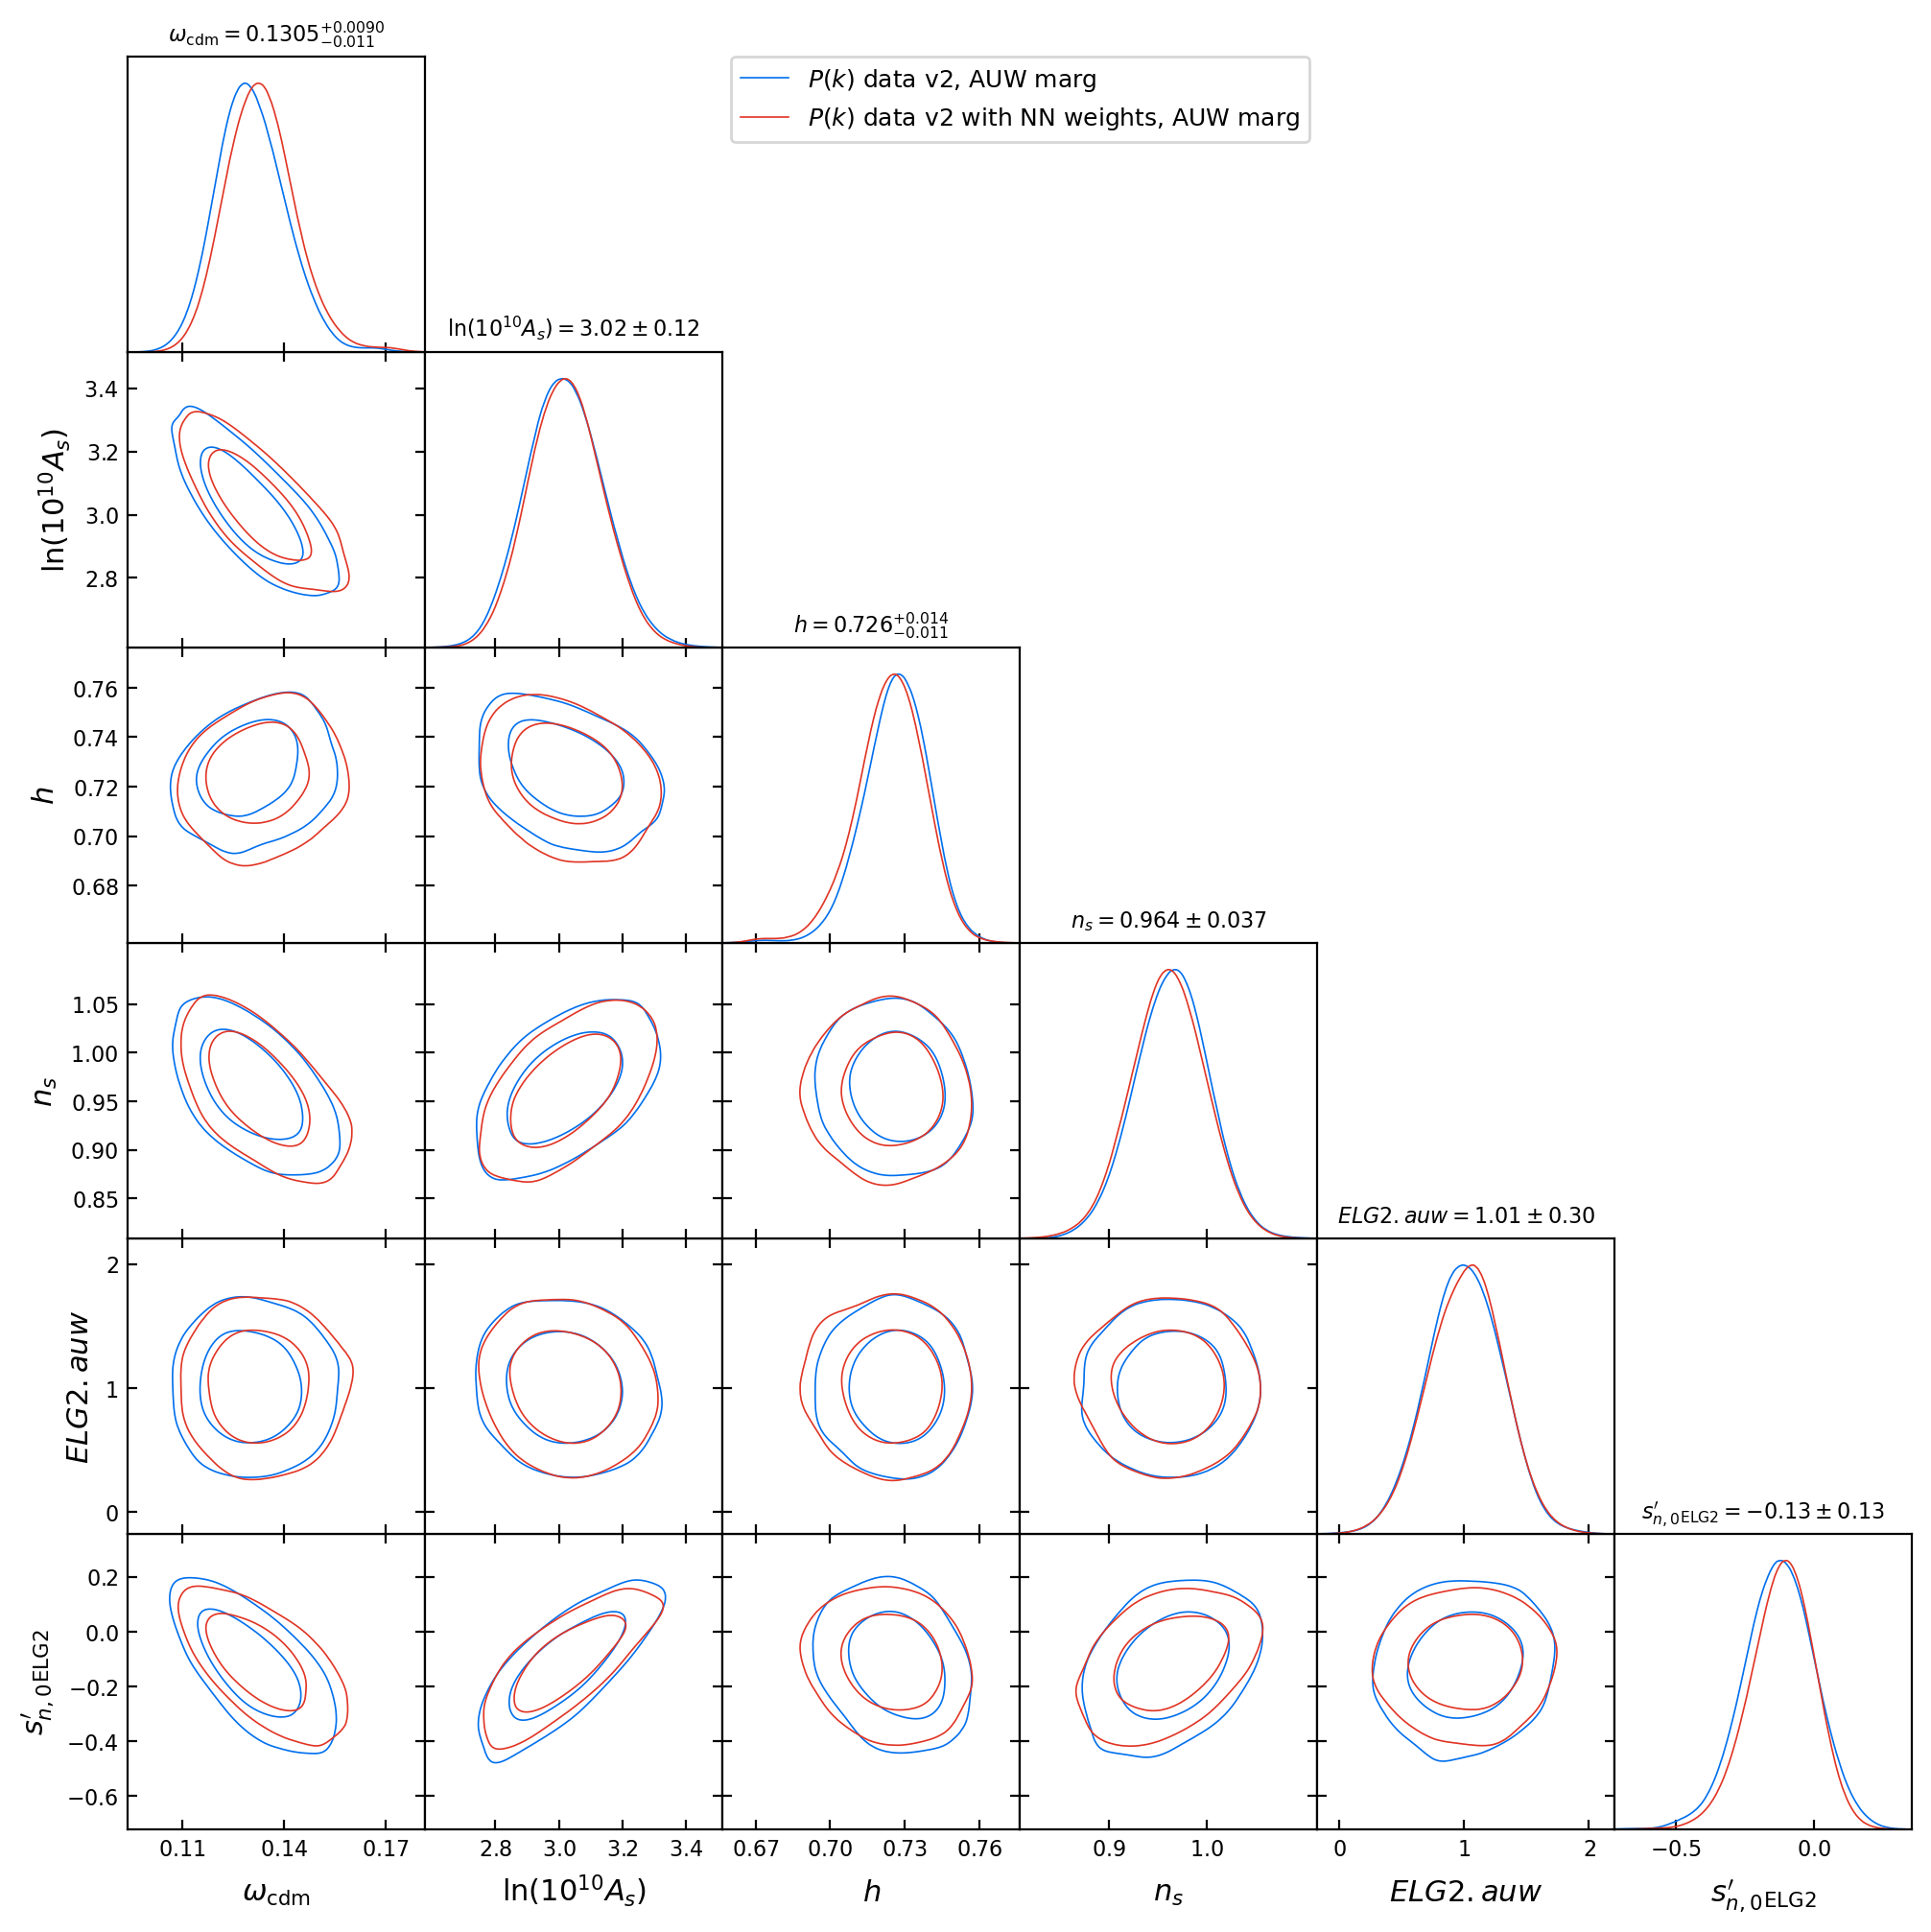

In [36]:
dirname = Path('/pscratch/sd/a/adematti/fits_systematic_templates/')
params_toplot = ['omega_cdm', 'logA', 'h', 'n_s', 'ELG2.auw', 'ELG2.sn0'] #, 'ELG2.b1', 'ELG2.b2', 'ELG2.bs', 'ELG2.c1', 'ELG2.snb0'] #['ELG2.alpha0', 'ELG2.alpha2', 'ELG2.alpha4', 'ELG2.sn0', 'ELG2.sn2', 'ELG2.sn4', 'ELG2.auw']

samples, legends = [], []
samples.append(read_samples([dirname / 'data-dr2-v2' / f'cosmo-base_ELG2-S2-w-auw-50e21258/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('$P(k)$ data v2, AUW marg')
samples.append(read_samples([dirname / 'data-dr2-test-maskedfraczpNN' / f'cosmo-base_ELG2-S2-w-auw-403adc77/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('$P(k)$ data v2 with NN weights, AUW marg')
plotting.plot_triangle(samples, params=params_toplot, title_limit=1, legend_labels=legends)
fig = plt.gcf()
fig.savefig(plot_dir / f'triangle_data_nn.{ext}', bbox_inches='tight', pad_inches=0.1, dpi=200)
plt.show()

Removed no burn in
Removed no burn in


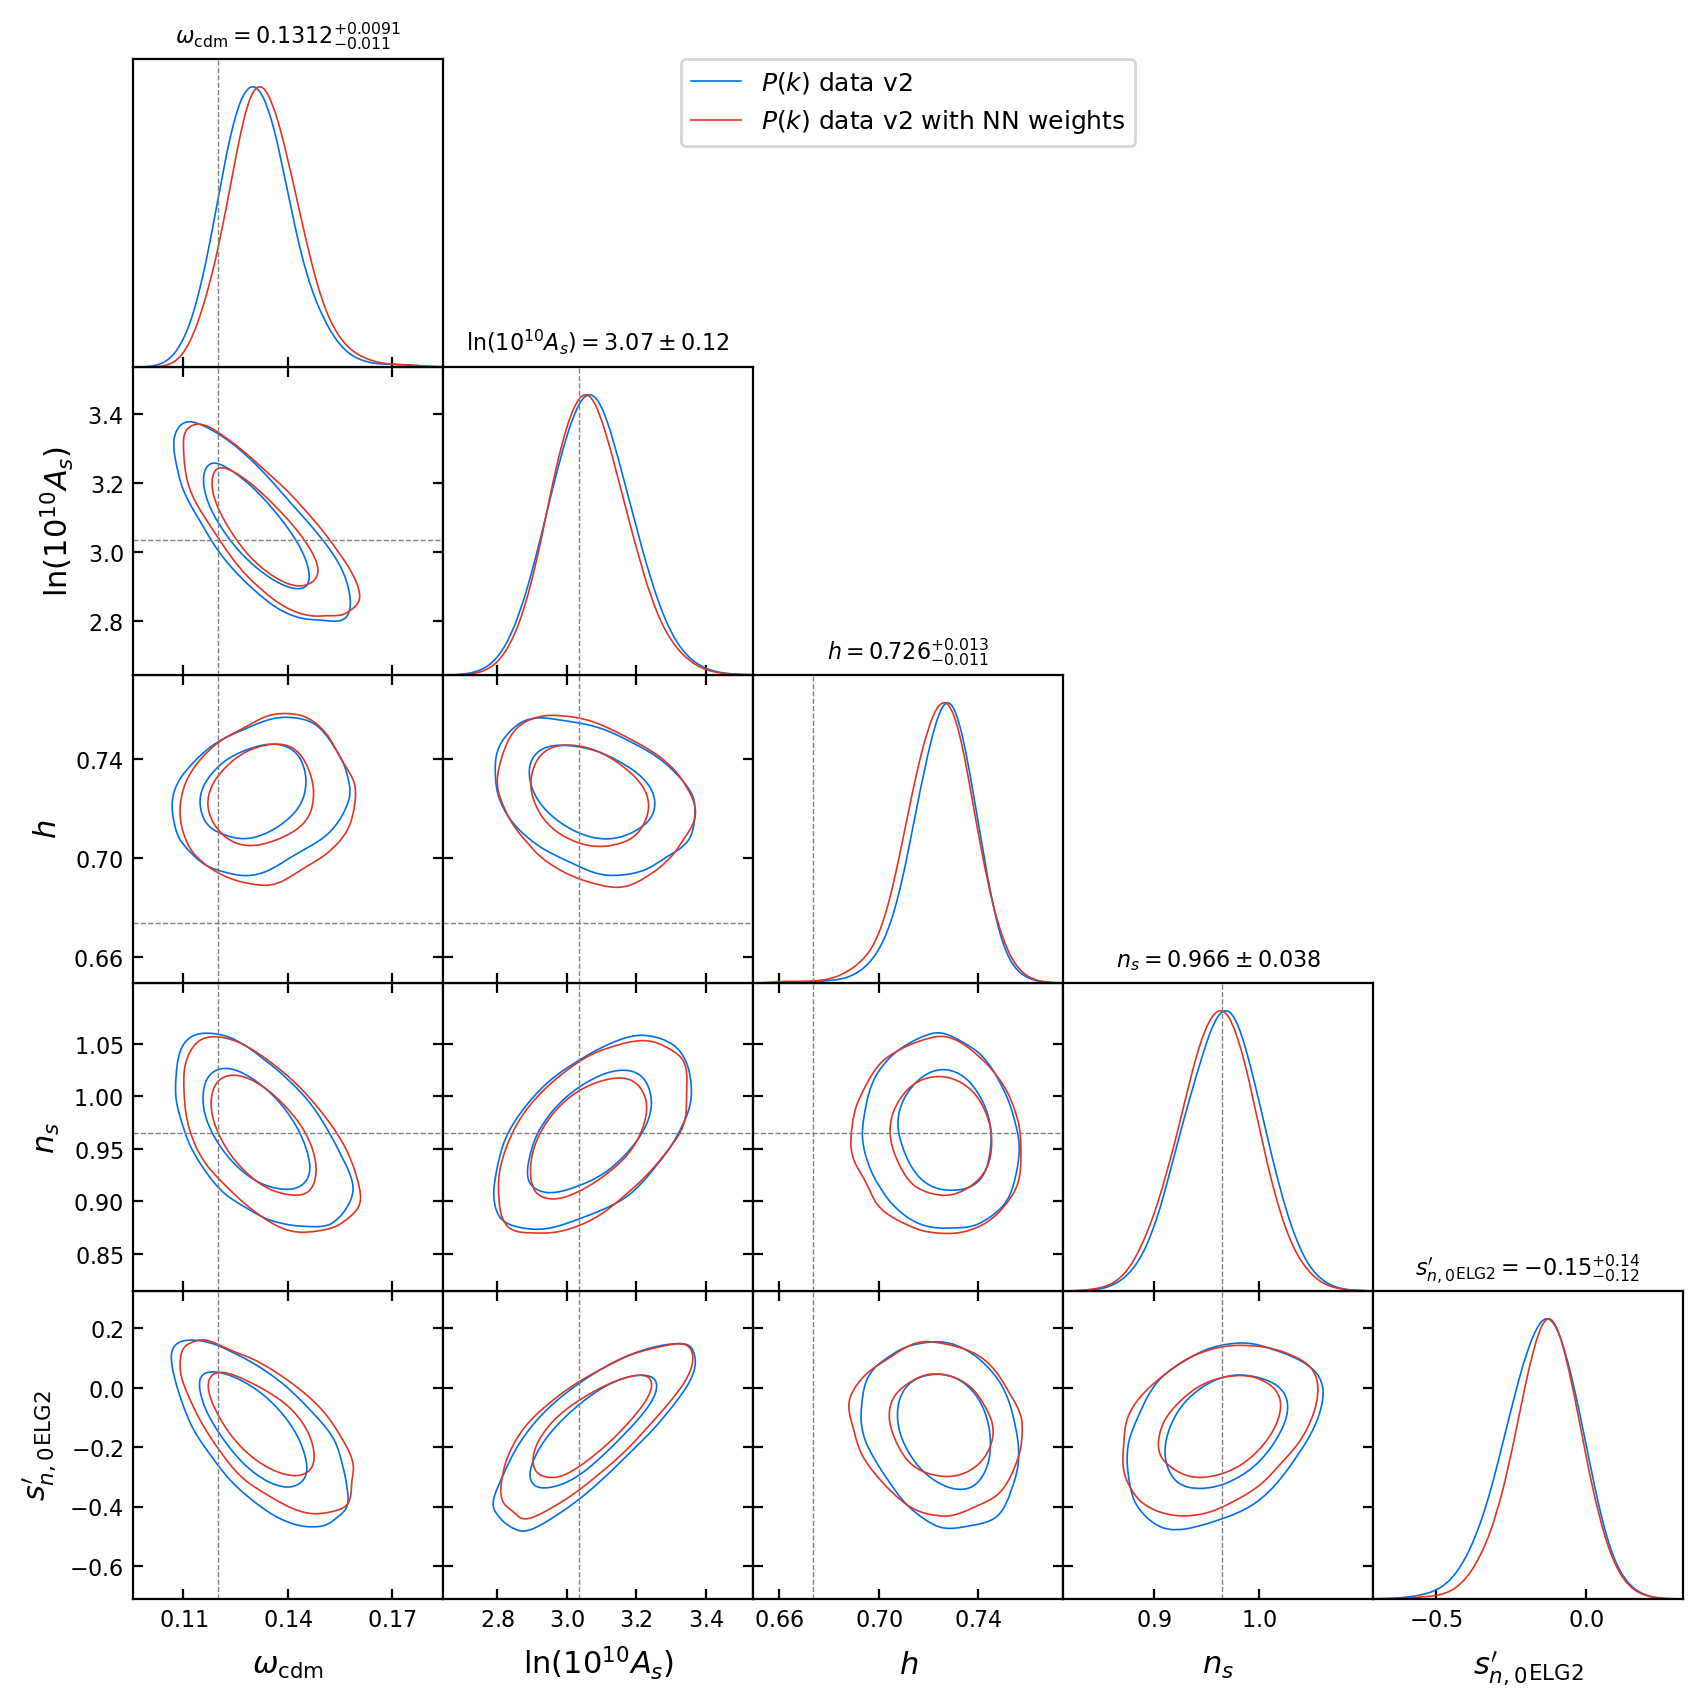

In [37]:
samples, legends = [], []
samples.append(read_samples([dirname / 'data-dr2-v2' / f'cosmo-base_ELG2-S2-ff1998b4/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('$P(k)$ data v2')
samples.append(read_samples([dirname / 'data-dr2-test-maskedfraczpNN' / f'cosmo-base_ELG2-S2-2f89d096/samples_{i + 1:d}.h5' for i in range(4)], burnin=0.3, thin=10))
legends.append('$P(k)$ data v2 with NN weights')
plotting.plot_triangle(samples, params=params_toplot, title_limit=1, markers=truth, legend_labels=legends)
fig = plt.gcf()
fig.savefig(plot_dir / f'triangle.{ext}', bbox_inches='tight', pad_inches=0.1, dpi=200)
plt.show()